In [1]:
import numpy as np
import matplotlib.pyplot as plt

Vi skal se hvordan vi kan flytte en figur i planen til en standard position.
Betragt en ottetalsfigur i planen givet ved
$$
x(t) = 3 \cos(t), \qquad y(t) = \sin(2t), \qquad \text{for } 0 \leq t \leq 2π
$$
Vi vil danne nogle datapunkter, som ligger tæt på en drejet version af denne
figur.

## (a) {-}

Plot kurven $(x(t), y(t))$ i python.

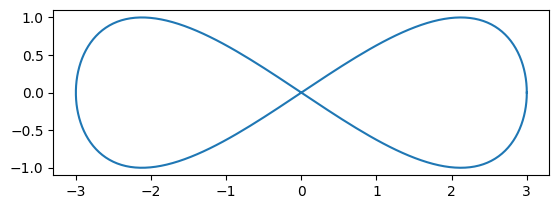

In [2]:
# x og y med de givne funktioner ud fra 200 værdier (t)
t = np.linspace(0, 2*np.pi, 200)
x = 3 * np.cos(t)
y = np.sin(2*t)

# opsætter 8-tals matricen som beskrevet
eight = np.array([x, y])

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(*eight)

## (b) {-}

Brug
```py
rng = np.random.default_rng()
theta = rng.uniform(...)
```
til at vælge en tilfældig vinkel $\theta$ mellem $\pi / 5$ og $4 \pi / 5$. Drej kurven med
rotationsmatricen $R = \begin{bmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{bmatrix}$ og plot resultatet

In [3]:
# Vælger en vinkel og opsætter rotationsmatricen som beskrevet
rng = np.random.default_rng()
theta = rng.uniform(np.pi/5, 4*np.pi / 5)
R = np.array([  [np.cos(theta), -np.sin(theta)],
                [np.sin(theta), np.cos(theta) ]])

print("R:\n", R)

R:
 [[-0.60300282 -0.79773906]
 [ 0.79773906 -0.60300282]]


$\pagebreak$

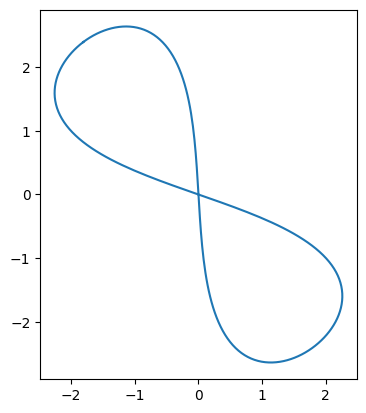

In [4]:
# Roterer 8-tals matricen
rotated = R @ eight

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(*rotated)

$\pagebreak$

## (c) {-}

For et rimeligt stort $n$, f.eks. $n = 2000$, dan en $(2 \times n)$-matrix hvis søjler
er tilfældige punkter fra den drejede kurve. Ved hjælp af

```py
rng.normal(0.0, 0.1, (2, n))
```

eller noget lignende, tilføj støj til alle indgange til at få en matrix $A$. Plot
punkterne i resultatet.

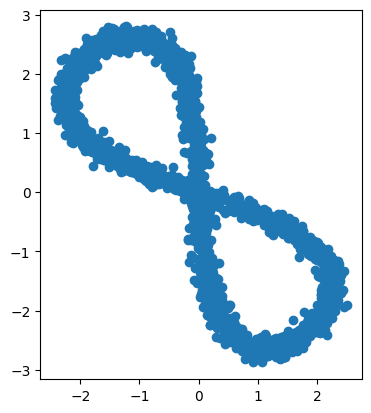

In [5]:
# Går efter eksemplet og vælger en n=2000
n = 2000
A = np.ones((2, n))

# For at få tilfældige punkter fra den drejede kurve bruges et for loop til at udvælge et tilfældigt ud af de 200 punkter på kurven
for i in range(n):
    point = rotated[:, np.random.randint(0, 200)]
    A[:,i] = point

# Støjen tilføjes som beskrevet
noise = rng.normal(0, 0.1, (2, n))
A += noise

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(*A, "o")

$\pagebreak$

## (d) {-}

For hver række i $A$, træk middelværdien fra, og dermed dan en ny matrix 𝐵
hvor hver række har middelværdi 0.
Der må gerne anvendes 
```py
np.mean(..., axis=..., ...)
```

In [6]:
# Den givne funktion bruges til at danne den nye B-matrix
B = A - np.mean(A, axis=1, keepdims=True)

# For at tjekke om hver række faktisk har en middelværdi på 0, skal middelværdierne først findes
B_row_avg = np.mean(B, axis=1, keepdims=True)

# Derefter tjekkes der om de er lig en 0-matrix med en tolerence på machine_epsilon da der bruges floats
machine_epsilon = np.finfo(float).eps
np.allclose(B_row_avg, np.zeros(B.shape), atol = machine_epsilon)

True

Da testen giver true må det betyde, at B blev opstillet korrekt.

## (e) {-}

In [7]:
u, s, vt = np.linalg.svd(B)
print("U:\n", u)
print("\nSingulærværdier:\n", s)

U:
 [[-0.60137925  0.7989637 ]
 [ 0.7989637   0.60137925]]

Singulærværdier:
 [95.11799498 32.05585137]


For at en matrix kan være ortogonal, skal dens transponerede ganget med sig selv give identitetsematricen. Matricen U kan da tjekkes om den er ortogonal på følgende måde, hvor false betyder den ikke er ortogonal, og true betyder at den er.

In [8]:
# Tjekker om produktet ut@u er lige identitetsmatricen
np.allclose(u.T @ u, np.eye(2), atol=machine_epsilon)

True

$\pagebreak$

## (f) {-}

Det vides at en punktsamling generelt kan beskrives som en ellipse. Denne ellipse vil have en stor- og lilleakse, som hhv. er den længste og korteste afstand fra ende til anden i ellipsen. En singulærværdidekomposition danner en ortogonal matrix $U$, som holder på retningen af stor- og lilleaksen. Da matricen er ortogonal angives retningen med singulærvektorer, som har længden 1 og ikke længden af den egentlige (halve) stor- og lilleakse. Længden kommer da fra den diagonale matrix $\Sigma$ (angivet som s i python delen), som holder på skaleringsværdierne fra singulærvektorer til de egentlige akser, også kaldt singulærværdier. Dette kan ses illustreret i nedenstående figur fra notesæt 10:

<!---
![SVD](Billeder/SVD.png)
---->
![SVD](C:/Users/henri/OneDrive%20-%20Aarhus%20universitet/2.%20Semester/Numerisk%20Lineær%20Algebra/TØ/Opgavesæt%207/Billeder/SVD.png)

Det kan ses på singulærværdierne, at den ene akse men singulærværdi på 95 må være meget større end den anden på 32. Derudover kan det ses, at de venstre singulærvektorer i $U$ peger mod hhv. negativ x, positiv y og positiv x, positiv y. Hvis akserne skulle afbildes, ville de nogenlunde se ud som således:

<!---
![eight](Billeder/eight.png)
---->
![eight](C:/Users/henri/OneDrive%20-%20Aarhus%20universitet/2.%20Semester/Numerisk%20Lineær%20Algebra/TØ/Opgavesæt%207/Billeder/eight.png)

## (g) {-}

Da SVD omdanner matricen til transformationer $U$ og $V^T$, men ottetallet kun er blevet roteret, må det betyde at $U$ holder på hele rotationen.

Det kan ses forneden at $U$ er symmetrisk:

In [15]:
print(u)

[[-0.60137925  0.7989637 ]
 [ 0.7989637   0.60137925]]


hvilket betyder at forholdet $U = U^T$ gælder. Derudover vides det for en ortogonal matrix at $U^T = U^{-1}$. Da matrixmultiplikation er kommutativt leder til, at et matrixprodukt mellem $U$ og $B$ vil være:
$$
B = U \Sigma V^T \\
\Downarrow \\
UB = U (U \Sigma V^t) \\
\Updownarrow \\
UB = U^{-1} U \Sigma V^T \\
UB = I_2 \Sigma V^T
$$
Da $U$ som beskrevet holdte på rotationen og den bliver til identitetsmatricen efter produktet tages må det betyde at $UB$ tager $B$ tilbage til den original position før rotationen (liggende). Dette kan ses forneden:

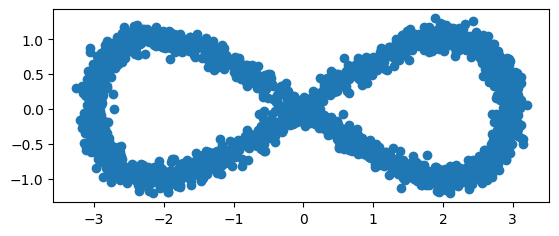

In [9]:
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(*(u @ B), 'o')